# Road Accident Analysis in Ghana: A Statistics-Driven Exploration




### Purpose of this Notebook
This notebook analyzes road accident data in Ghana using statistical and mathematical foundations, not machine learning models. The goal is to understand patterns, variability, and relationships in the data through statistics, then communicate insights clearly using visualizations.

We begin by understanding the structure of the data, clean missing values, and normalize accident counts by population. We then explore distributions and variability, test whether observed differences are statistically meaningful, and finally examine long-term trends in road safety.


## Problem Context

Road accidents remain a major public safety concern in Ghana. Understanding how accident cases and fatalities behave across time and regions is critical for planning, prevention, and policy decisions.

Instead of jumping straight into predictive models, this analysis focuses on **understanding the data deeply first using statistics.**



## Research Questions

I have structured the analysis around the following questions:



1.   How have road accident cases and fatalities changed over time?
2.   How do regions differ in accident and fatality levels?
3.   How variable are these outcomes, and are there extreme patterns?
4.   Which statistical measures best summarize road accident data?









# Importing Required Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Loading the Dataset
We begin by loading the CSV file containing road accident data.

In [38]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv("/content/ghana_road_accidents_2010_2025.csv")

# Display the first 10 rows
df.head(10)

,year,region,incidents,fatalities,population,urban_rural
0,2010,Greater Accra,12400,2050.0,4010000,Urban
1,2010,Ashanti,9800,1800.0,4830000,Urban
2,2010,Eastern,6100,950.0,2580000,Urban
3,2010,Central,5400,820.0,2300000,Urban
4,2010,Western,5800,870.0,2370000,Urban
5,2010,Western North,3200,520.0,850000,Rural
6,2010,Volta,4200,610.0,2100000,Rural
7,2010,Oti,2800,450.0,750000,Rural
8,2010,Northern,3900,740.0,2940000,Rural
9,2010,Savannah,2600,480.0,600000,Rural


# Understanding the Data Structure

Before analysis, we inspect the dataset to understand its structure, variables, and data types to help identify numerical variables, reveals missing values and guides preprocessing decisions

In [39]:
# Check dataset structure
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         256 non-null    int64  
 1   region       256 non-null    object 
 2   incidents    256 non-null    int64  
 3   fatalities   255 non-null    float64
 4   population   256 non-null    int64  
 5   urban_rural  256 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 12.1+ KB


In [40]:
df.describe()

,year,incidents,fatalities,population
count,256.000000,256.000000,255.000000,2.560000e+02
mean,2017.500000,5921.093750,986.078431,2.022617e+06
std,4.618802,3263.719816,562.439423,1.396303e+06
min,2010.000000,2400.000000,430.000000,5.200000e+05
25%,2013.750000,3800.000000,650.000000,9.500000e+05
50%,2017.500000,4700.000000,820.000000,1.280000e+06
75%,2021.250000,6700.000000,1015.000000,2.725000e+06
max,2025.000000,17500.000000,3050.000000,5.800000e+06


In [41]:
# Descriptive statistics for numeric columns that exist at this stage
desc_stats = df[['incidents', 'fatalities', 'population']].describe()
desc_stats

,incidents,fatalities,population
count,256.000000,255.000000,2.560000e+02
mean,5921.093750,986.078431,2.022617e+06
std,3263.719816,562.439423,1.396303e+06
min,2400.000000,430.000000,5.200000e+05
25%,3800.000000,650.000000,9.500000e+05
50%,4700.000000,820.000000,1.280000e+06
75%,6700.000000,1015.000000,2.725000e+06
max,17500.000000,3050.000000,5.800000e+06


# Handling Missing Values

Missing values can distort statistical calculations. Since our dataset contains numerical variables, we handle missing values using appropriate statistical measures.

In [42]:
# Check for missing values
df.isna().sum()

,0
year,0
region,0
incidents,0
fatalities,1
population,0
urban_rural,0


In [43]:
# Opt into future pandas behavior to avoid silent type conversion warnings
pd.set_option('future.no_silent_downcasting', True)

# Replace missing values (NaN) in the 'fatalities' column with the column's average
df['fatalities'] = df['fatalities'].fillna(df['fatalities'].mean())

# Confirm missing values are handled
df.isnull().sum()



,0
year,0
region,0
incidents,0
fatalities,0
population,0
urban_rural,0


# Feature Engineering (Accident Rate per 100k population)

Raw accident counts can be misleading because regions have very different population sizes. Rates allow fair comparison so we will use rate per 100k population

In [44]:
# Creating a new column: accident rate per 100,000 population
df['accident_rate'] = (df['incidents'] / df['population']) * 100000

# Creating a new column: fatality rate per 100,000 population
df['fatality_rate'] = (df['fatalities'] / df['population']) * 100000

# Display first 10 rows to check
df.head(10)



,year,region,incidents,fatalities,population,urban_rural,accident_rate,fatality_rate
0,2010,Greater Accra,12400,2050.0,4010000,Urban,309.226933,51.122195
1,2010,Ashanti,9800,1800.0,4830000,Urban,202.898551,37.267081
2,2010,Eastern,6100,950.0,2580000,Urban,236.434109,36.821705
3,2010,Central,5400,820.0,2300000,Urban,234.782609,35.652174
4,2010,Western,5800,870.0,2370000,Urban,244.725738,36.708861
5,2010,Western North,3200,520.0,850000,Rural,376.470588,61.176471
6,2010,Volta,4200,610.0,2100000,Rural,200.000000,29.047619
7,2010,Oti,2800,450.0,750000,Rural,373.333333,60.000000
8,2010,Northern,3900,740.0,2940000,Rural,132.653061,25.170068
9,2010,Savannah,2600,480.0,600000,Rural,433.333333,80.000000


# Descriptive Statistics

Descriptive statistics summarize data so we can understand its central tendency, spread, and shape. Helps understand the **central tendency** and **spread** of our data.

In [45]:
# Descriptive statistics for numeric columns
desc_stats = df[['incidents', 'fatalities', 'population', 'accident_rate', 'fatality_rate']].describe()
desc_stats


,incidents,fatalities,population,accident_rate,fatality_rate
count,256.000000,256.000000,2.560000e+02,256.000000,256.000000
mean,5921.093750,986.078431,2.022617e+06,338.492153,57.301005
std,3263.719816,561.335517,1.396303e+06,91.651719,18.280982
min,2400.000000,430.000000,5.200000e+05,132.653061,25.170068
25%,3800.000000,650.000000,9.500000e+05,260.553471,39.376859
50%,4700.000000,820.000000,1.280000e+06,357.037037,58.793208
75%,6700.000000,1012.500000,2.725000e+06,413.147993,72.693452
max,17500.000000,3050.000000,5.800000e+06,488.888889,86.666667


In [46]:
# Calculating skewness for each numeric column — skewness measures how symmetrical
# the data is. A score near 0 is balanced, positive means a long right tail
# (most values are low with a few very high outliers), and negative means a long
# left tail. This helps us spot columns that may need transformation before modeling.

desc_stats.skew()

,0
incidents,2.001678
fatalities,2.336368
population,1.719920
accident_rate,-0.193038
fatality_rate,2.323839


# Visualizing Distributions

Visuals help confirm what statistics suggest

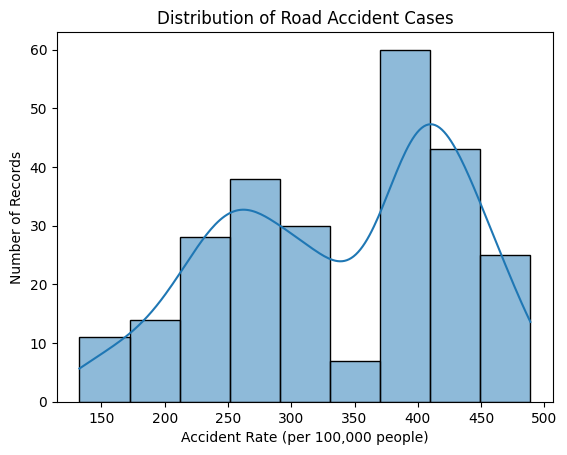

In [47]:
# Distribution of accident cases
plt.figure()
sns.histplot(df['accident_rate'], kde=True)
plt.title('Distribution of Road Accident Cases')
plt.xlabel('Accident Rate (per 100,000 people)')   # explains what the numbers mean
plt.ylabel('Number of Records')
plt.show()

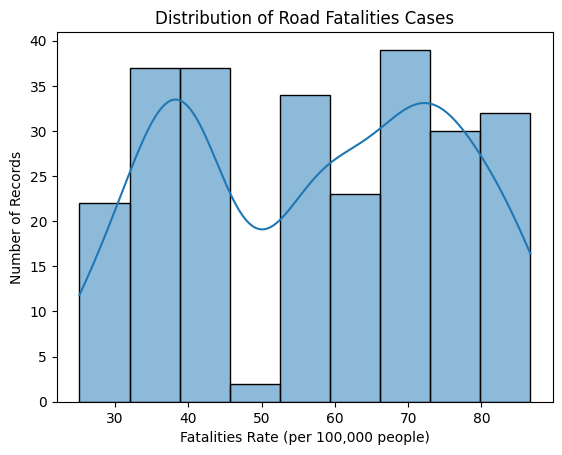

In [48]:
# Distribution of fatalities cases
plt.figure()
sns.histplot(df['fatality_rate'], kde=True)
plt.title('Distribution of Road Fatalities Cases')
plt.xlabel('Fatalities Rate (per 100,000 people)')   # explains what the numbers mean
plt.ylabel('Number of Records')
plt.show()

## Step 7: Poisson Distribution. Understanding How Accidents Behave


The **Poisson distribution** is a mathematical model used to describe events
that happen randomly over time or space. It was designed for situations where:

- Events happen **randomly** : you cannot predict exactly when the next one occurs
- Events happen **independently** : one accident does not cause the next one
- Events happen at a **roughly steady average rate** over time

Road accidents in Ghana fit this description perfectly.

### What does this have to do with our chart?

The histogram below showing our real accident data is doing exactly what a
Poisson model would predict:

- Most regions cluster around a **common middle value** — the average
- Very low and very high accident counts appear **less frequently**
- The KDE curve peaks near the average and then drops off on both sides

This peaked, right-skewed shape is consistent with Poisson-type event data..

### What are we trying to achieve?

By understanding that accidents follow a Poisson pattern, we can say with
confidence that accident counts in Ghana are **not random noise** — they follow
a predictable statistical pattern. This means the average we calculated is a
reliable and meaningful number, not just a guess.


The average number of incidents is: 5921.09375


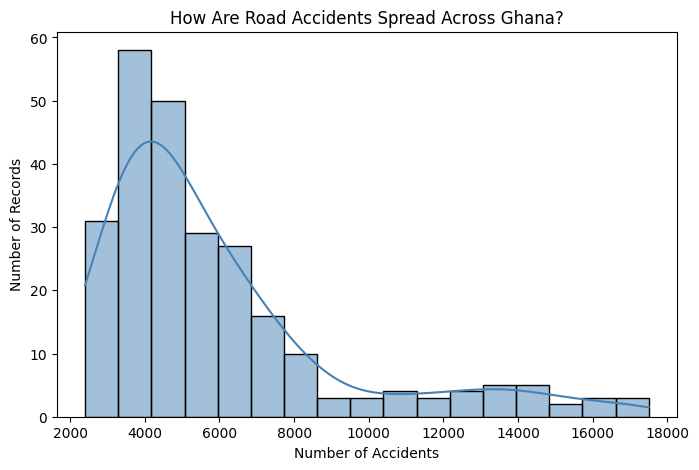

In [49]:
# Step 1: Find the average number of incidents
average_incidents = df['incidents'].mean()
print(f'The average number of incidents is: {average_incidents}')

# CHART 1: Our real accident data from Ghana
plt.figure(figsize=(8, 5))
sns.histplot(df['incidents'], kde=True, color='steelblue')
plt.title('How Are Road Accidents Spread Across Ghana?')
plt.xlabel('Number of Accidents')
plt.ylabel('Number of Records')
plt.show()

The average number of incidents is: 5921.09375


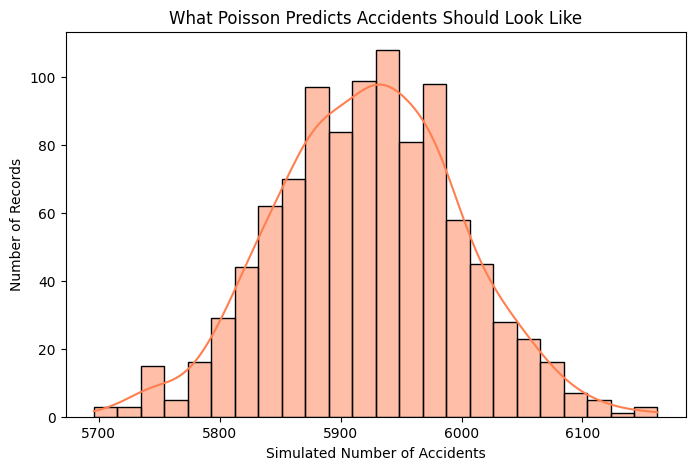

In [50]:
# We use the average from our real data as the base for the simulation
average_incidents = df['incidents'].mean()
print(f'The average number of incidents is: {average_incidents}')


# np.random.poisson generates random numbers that follow a Poisson pattern
# we generate 1000 of them using our real average as the guide
poisson_data = np.random.poisson(average_incidents, 1000)

# CHART 2: Poisson model — simulating what random accidents should look like
plt.figure(figsize=(8, 5))
sns.histplot(poisson_data, kde=True, color='coral')
plt.title('What Poisson Predicts Accidents Should Look Like')
plt.xlabel('Simulated Number of Accidents')
plt.ylabel('Number of Records')
plt.show()

# Covariance and Correlation

Covariance measures whether two variables increase or decrease together.
A positive value means they move in the same direction.
However, covariance is affected by scale, making it hard to compare directly.

In [51]:
# Covariance matrix
cov_matrix = df[['incidents','fatalities','accident_rate','fatality_rate']].cov()
cov_matrix

# Correlation matrix
corr_matrix = df[['incidents','fatalities','accident_rate','fatality_rate']].corr()
corr_matrix


,incidents,fatalities,accident_rate,fatality_rate
incidents,1.000000,0.985136,-0.423002,-0.409145
fatalities,0.985136,1.000000,-0.367071,-0.320362
accident_rate,-0.423002,-0.367071,1.000000,0.970772
fatality_rate,-0.409145,-0.320362,0.970772,1.000000


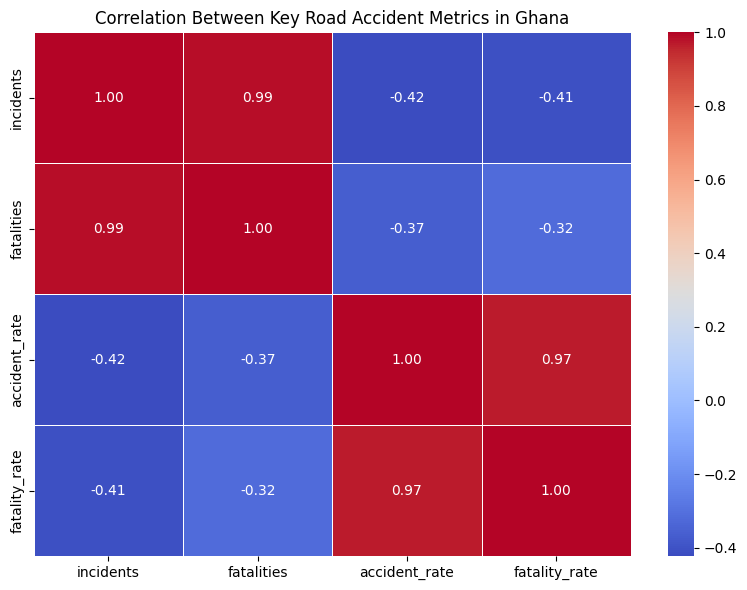

In [52]:
# Visualize the correlation matrix as a heatmap for easy interpretation
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Key Road Accident Metrics in Ghana')
plt.tight_layout()
plt.show()

## Step 8: Central Limit Theorem — Can We Trust Our Averages?

Our accident data is skewed. A few regions like Greater Accra have very high
accident numbers which makes the data uneven. So can we still trust the
averages we calculate? The Central Limit Theorem says yes — and here is why.

### The idea in plain English

Imagine you ask 50 random students their height and calculate the average.
Then you do it again with a different 50 students. You repeat this 1000 times.
Even if the school has some extremely tall and short students throwing things off,
your 1000 averages will always cluster together and form a bell curve shape.

That is exactly what the Central Limit Theorem says:

> No matter how messy your data is, if you take enough random samples,
> the averages of those samples will always form a bell curve.

### What we are doing in the code below

We pick 50 random rows from our accidents data, calculate their average,
and repeat this 1000 times. We then plot all 1000 averages. If they form
a bell curve, it means our data follows the Central Limit Theorem.

### Why this matters for our project

At the end of the code you will see two numbers printed — the average of
our 1000 samples and the real average from our full dataset. If they are
close to each other, it confirms that our statistics are trustworthy and
not being thrown off by extreme regions like Greater Accra.

In short — the Central Limit Theorem gives us confidence that our findings
are reliable and meaningful, not just a result of messy skewed data.

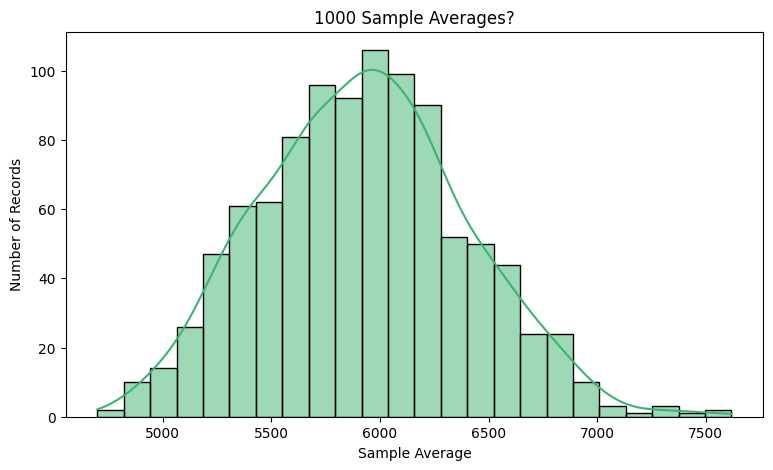

Average of our 1000 samples: 5927.346
Real average from our data: 5921.09375


In [53]:
# We are going to take 1000 random samples from our data
# and record the average of each sample
# At the end, all those averages should form a bell curve
# This is called the Central Limit Theorem

sample_means = []

# Repeat 1000 times
for _ in range(1000):
    # Pick 50 random rows from our incidents column
    sample = df['incidents'].sample(50, replace=True)
    # Calculate the average of those 50 rows and save it
    sample_means.append(sample.mean())

# Plot all 1000 averages — it should look like a bell curve
plt.figure(figsize=(9, 5))
sns.histplot(sample_means, kde=True, color='mediumseagreen')
plt.title('1000 Sample Averages?')
plt.xlabel('Sample Average')
plt.ylabel('Number of Records')
plt.show()

# Compare our sample average to the real average
print(f'Average of our 1000 samples: {np.mean(sample_means)}')
print(f'Real average from our data: {df["incidents"].mean()}')

Up to this point, we have been exploring patterns. We now move into inferential statistics, where we test whether observed differences are real or due to chance

## T-Test — Are Urban Areas More Dangerous Than Rural Areas?

We can see from our charts that urban areas seem to have more accidents than
rural areas. But is that difference real or could it just be random chance?

The **T-Test** answers exactly this question. It compares two groups and tells
us whether the difference between them is statistically meaningful.

The key number to look at is the **p-value**:
- Below 0.05 = the difference is real and not random
- Above 0.05 = the difference could just be chance

Let us test whether urban and rural areas in Ghana have genuinely different
accident counts.

In [54]:
# Split our data into two groups: urban and rural
urban = df[df['urban_rural'] == 'Urban']['incidents']
rural = df[df['urban_rural'] == 'Rural']['incidents']

# Print the average for each group so we can see the difference
print(f'Average accidents in Urban areas: {urban.mean()}')
print(f'Average accidents in Rural areas: {rural.mean()}')

# Run the t-test to check if the difference is real or just random
t_stat, p_value = stats.ttest_ind(urban, rural)

print(f'P-value: {p_value}')

# Automatically tell us what the result means
if p_value < 0.05:
    print('Result: YES — Urban and Rural accidents are significantly different')
else:
    print('Result: NO — The difference could just be random chance')

Average accidents in Urban areas: 8340.17857142857
Average accidents in Rural areas: 4039.5833333333335
P-value: 9.45955484600843e-33
Result: YES — Urban and Rural accidents are significantly different


## Step 9b: ANOVA — Are Some Regions Significantly More Dangerous?

The T-Test only compares two groups. But we have 16 regions in Ghana.
How do we know if the differences between all 16 regions are real?

This is where **ANOVA** comes in. ANOVA works like a T-Test but for
more than two groups at once. It asks:

> Are the differences we see across all 16 regions real, or could they
> just be random chance?

Again, the key number is the **p-value**:
- Below 0.05 = the regional differences are real
- Above 0.05 = the differences could just be chance

In [55]:
# Group our accident data by region
# This creates one group of numbers for each of the 16 regions
groups = [group['incidents'].values for _, group in df.groupby('region')]

# Run ANOVA across all 16 regional groups at once
f_stat, p_anova = stats.f_oneway(*groups)

print(f'P-value: {p_anova}')

# Automatically tell us what the result means
if p_anova < 0.05:
    print('Result: YES — Accident counts are significantly different across regions')
else:
    print('Result: NO — Regional differences could be due to random chance')

P-value: 1.785403743486223e-136
Result: YES — Accident counts are significantly different across regions


### What do these results tell us?

Together the T-Test and ANOVA give our project statistical credibility.
Instead of just saying "urban areas look more dangerous" or "some regions
seem worse than others", we can now say it with mathematical confidence —
backed by evidence, not just observation.

# Visualizations

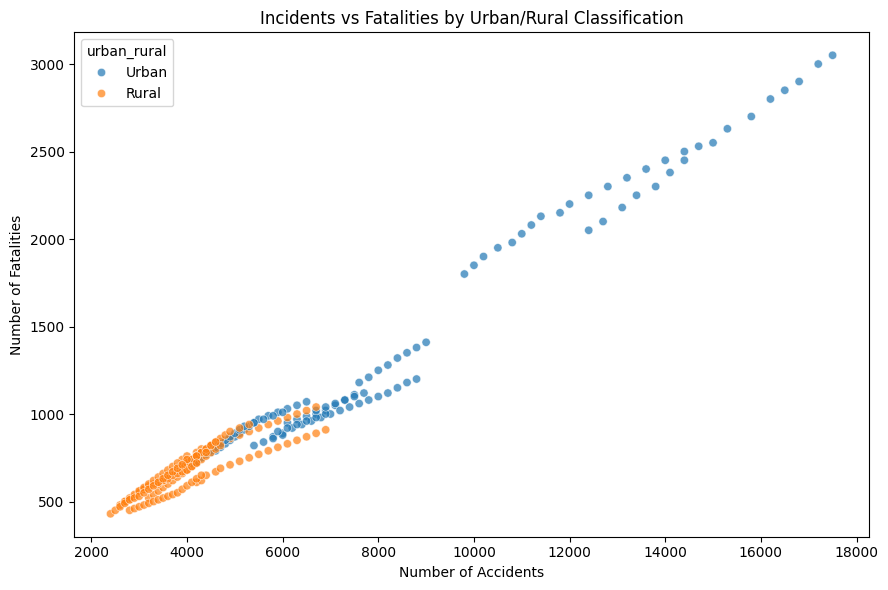

In [56]:
# SCATTER PLOT: Incidents vs Fatalities
# Shows the relationship between accident count and deaths, split by urban/rural
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='incidents', y='fatalities', hue='urban_rural', alpha=0.7)
plt.title('Incidents vs Fatalities by Urban/Rural Classification')
plt.xlabel('Number of Accidents')
plt.ylabel('Number of Fatalities')
plt.tight_layout()
plt.show()

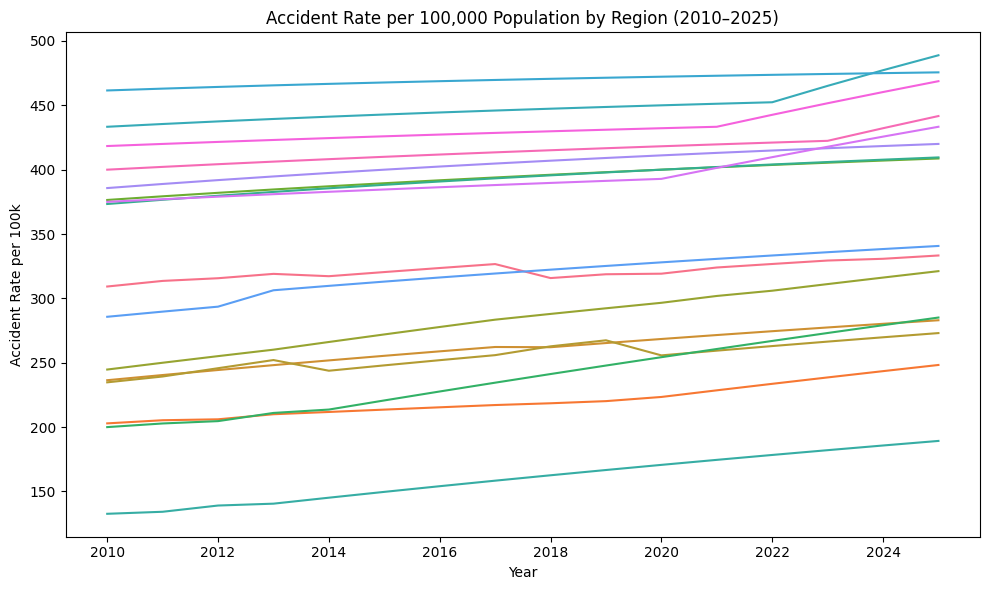

In [57]:
# LINE PLOT: Accident Rate Over Time by Region
# Tracks how accident rates per 100,000 people have changed from 2010 to 2025
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='accident_rate', hue='region', legend=False)
plt.title('Accident Rate per 100,000 Population by Region (2010–2025)')
plt.xlabel('Year')
plt.ylabel('Accident Rate per 100k')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3804172444.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_fatality.index, y=region_fatality.values, palette='Reds_r')


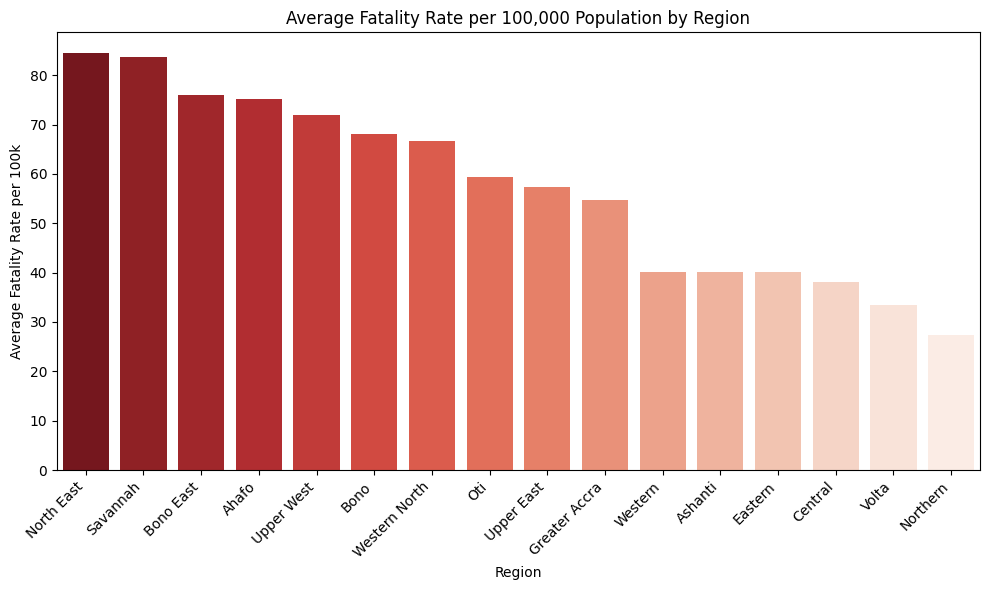

In [58]:
# BAR CHART: Average Fatality Rate by Region
# Ranks regions by how deadly accidents are relative to population size
region_fatality = df.groupby('region')['fatality_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_fatality.index, y=region_fatality.values, palette='Reds_r')
plt.title('Average Fatality Rate per 100,000 Population by Region')
plt.xlabel('Region')
plt.ylabel('Average Fatality Rate per 100k')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Trend Analysis

**Reading the trend:**  
The slope tells us by how many incidents per year the average is changing. A positive slope is a warning sign. It means Ghana's roads are getting more dangerous over time, which has direct implications for policy, infrastructure investment, and public safety campaigns.

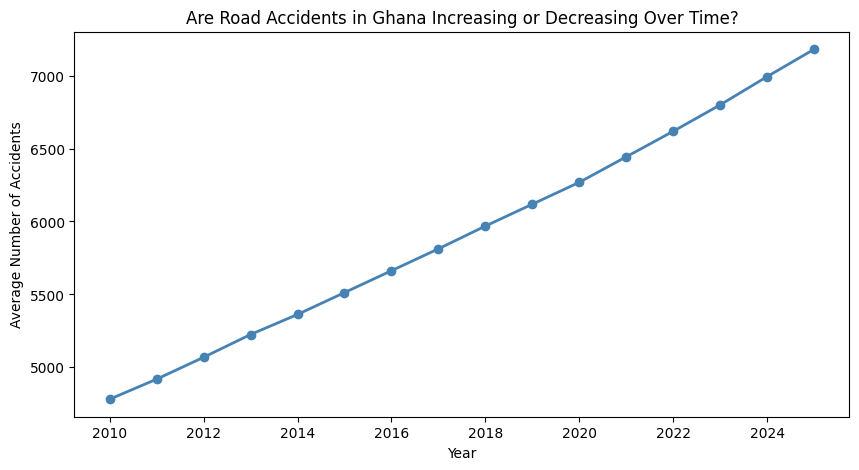

Average accidents in 2010: 4781.25
Average accidents in 2025: 7181.25
Overall trend: INCREASING — accidents are going up over time


In [59]:
# Calculate the average number of accidents for each year
yearly_trend = df.groupby('year')['incidents'].mean()

# Plot the trend so we can see if accidents are going up or down over time
plt.figure(figsize=(10, 5))
yearly_trend.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Are Road Accidents in Ghana Increasing or Decreasing Over Time?')
plt.xlabel('Year')
plt.ylabel('Average Number of Accidents')
plt.show()

# Check if the trend is going up or down
# We do this by comparing the first year average to the last year average
first_year = yearly_trend.iloc[0]
last_year = yearly_trend.iloc[-1]

print(f'Average accidents in 2010: {first_year}')
print(f'Average accidents in 2025: {last_year}')

if last_year > first_year:
    print('Overall trend: INCREASING — accidents are going up over time')
else:
    print('Overall trend: DECREASING — accidents are going down over time')